# CECo Homework 1 (partial)Solution

#### Foreword:<br>
This notebook proposes elements of solution to the Homework 1. It only represents one way of approaching the problem. It does not follows the list of instructions strictly, and it does not contain all calculations and numerical results.<br>

It might be frustrating to see that this approach is quite simplistic, but remember that scientific discovery isn't made by applying the same recipe over and over, it is made by adapting what you know to new problems.<br>

#### General feedback:<br>
All of you did a great job. I was very satisfied and impressed by the effort you put in this. Thank you for taking this exercise seriously. Special thanks for those who said they used chatgpt to learn methods or get ideas to overcome challenges. You have a tool, use it.<br>

The first planet did not constitute any difficulty. I did notice that some of you went for planet d first (4800 days, visible by eye in the data), but some of you preferred the robust methodology of doing a Lomb-Scargle and using the known period to fit planet b first (14 days, strongest signal). Both were equally successful.
I did note that most of you did not compute the RMS after the first fit, it’s a bit unfortunate since this is your quantitative way of saying “yes the fit worked”.<br>

Most of you had issues with the formulas to compute the mass, or its uncertainty, or Teq, or sigma_Teq. It is especially unfortunate since mass and sigma_mass functions were given in Activity 1. I highly recommend you do the derivations again.

#### Brief description of the approach presented here:<br>
Scientists are not magicians: they cannot extract information from data that isn't there.<br>
But scientists are smart: don't use a bazooka to kill a fly. Ideally, you want your work/effort to match the quality of data.<br>

I chose to fit planet d first (4800 days) because it's easy to see visually, so it will be easy to fit and confirm visually. However, I know that 1-planet fit will never be sufficient. Therefore, I don't need to deploy a bazooka and over-interpret it. The fit worked but is insufficient -> moving on.<br>

The other thing is that most planets are well fitted by a sine wave. I don't want to go through the pain of carrying eccentricities and angles of passage at periastron. If I see that it's insufficient, I will add eccentricity later. (spoiler alert: I did not)<br> 


#### Multiple single planet or single multi planet fit:<br>
Your physical signal can be decomposed like this:
$$ y_\mathrm{data} = y_\mathrm{planet1} + y_\mathrm{planet2} + y_\mathrm{planet3} + y_\mathrm{noise}$$
Note that the 'noise' is not the uncertainty, it can represent actual noise (e.g. from the instrument) or effects of physical origin that we don't account for. The noise can be bigger than the uncertainty (and it is the case here).<br>

When fitting the 1st planet (no matter which), you obtain $y_\mathrm{model1}$ which is close to $y_\mathrm{planet1}$ but slightly off (because of uncertainty and noise). Call it $y_\mathrm{off1} = y_\mathrm{planet1} - y_\mathrm{model1}$. So when you analyse the first residuals you have:
$$ r_\mathrm{1} = y_\mathrm{data} - y_\mathrm{model1} = y_\mathrm{off1} + y_\mathrm{planet2} + y_\mathrm{planet3} + y_\mathrm{noise}$$
These residuals 1 are smaller than data, but notice the presence of $y_\mathrm{off1}$.<br>

When you fit the 2nd planet, you get new residuals:
$$ r_\mathrm{2} = y_\mathrm{off1} + y_\mathrm{off2} + y_\mathrm{planet3} + y_\mathrm{noise}$$

Do you notice the problem**S**?<br>
First, these offsets accumulate. If the first fit was approximate, $y_\mathrm{off1}$ is not negligible and will remain there after all other fits.<br>
Second, and most importantly, when fitting for the 2nd planet, the fit will be impacted by $y_\mathrm{off1}$. This means if the first fit is of poor quality, $y_\mathrm{off1}$ is not negligible, and this will make all subsequent fits worse. And the real danger is that $y_\mathrm{off1}$ has structure (it is not pure noise), meaning it can be mistaken for signal at a later stage.<br>
And since these offsets accumulate, when fitting the 4th planet, your data contains $y_\mathrm{off1} + y_\mathrm{off2} + y_\mathrm{off3}$, and so on...<br>

This is why it is important to do a multi-planet fit.

### First import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle

def rms(x):
    '''
    Return the RMS of a numpy array
    '''
    return np.sqrt(np.mean(x**2))

# Modeling the Radial Velocity Data

### Read in data

First, read in the RV data and plot it.

              HJD          RV  RV_err
0    2.449676e+06  131.910004    4.84
1    2.449768e+06   22.600000    2.57
2    2.449769e+06   -5.490000    2.68
3    2.449794e+06  107.309998    1.52
4    2.450057e+06  116.669998    1.62
..            ...         ...     ...
269  2.455584e+06   18.170000    1.06
270  2.455585e+06   -9.750000    1.15
271  2.455586e+06  -45.720001    1.83
272  2.455603e+06  -41.410000    0.96
273  2.455604e+06  -17.950001    1.09

[274 rows x 3 columns]


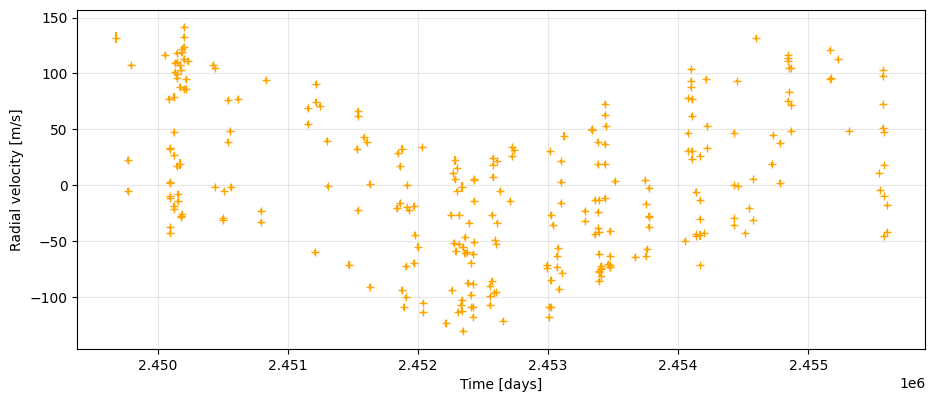

In [2]:
### Read in the data

rv_data = pd.read_csv("rv_55cnc.txt",delimiter=r'\s+',skiprows=22,header=None,names=["HJD","RV","RV_err"])

# ---- Print ----
print(rv_data)

# ---- Plot ----
plt.errorbar(rv_data["HJD"],rv_data["RV"],yerr=rv_data["RV_err"],marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
plt.show()


## 1 planet analysis

No time to loose. The data clearly looks like a sine function. Let's define a sine wave and fit our data with it!

In [3]:
# model with 1 planet
def rv_model1(time, Vz, K1, P1, T1):

    rv = K1*np.sin(2.0*np.pi*(time-T1)/P1) + Vz
    
    return rv

This is a very easy fit, so a rough estimate of each parameters and no bounds will do the trick.

In [4]:
# initial guesses
K1 = 100.0
P1 = 5000.0
T1 = 4000.0 
Vz = 0

# array containing initial guesses
p_init = np.asarray([Vz,K1,P1,T1])

x = rv_data["HJD"]-rv_data["HJD"][0]
y = rv_data["RV"]
yerr = rv_data["RV_err"]

param_opt1, pcov1 = curve_fit(
    rv_model1,
    x,
    y,
    p0=p_init,
    sigma=yerr,
    absolute_sigma=True
)

param_err1 = np.sqrt(np.diag(pcov1))

# -------------------------------------------------------
# 5) Print comparison table
# -------------------------------------------------------
param_names = ["Vz", "K1", "P1", "T1"]

df = pd.DataFrame({
    "Parameter": param_names,
    "Initial guess": p_init,
    "Best fit": param_opt1,
    "1σ uncertainty": param_err1
})

display(df)

,Parameter,Initial guess,Best fit,1σ uncertainty
0,Vz,0.0,-1.418196,0.099791
1,K1,100.0,47.917696,0.119918
2,P1,5000.0,4807.046793,9.720716
3,T1,4000.0,4221.912786,2.670276


The fit seems to have worked. Let's inspect visually.

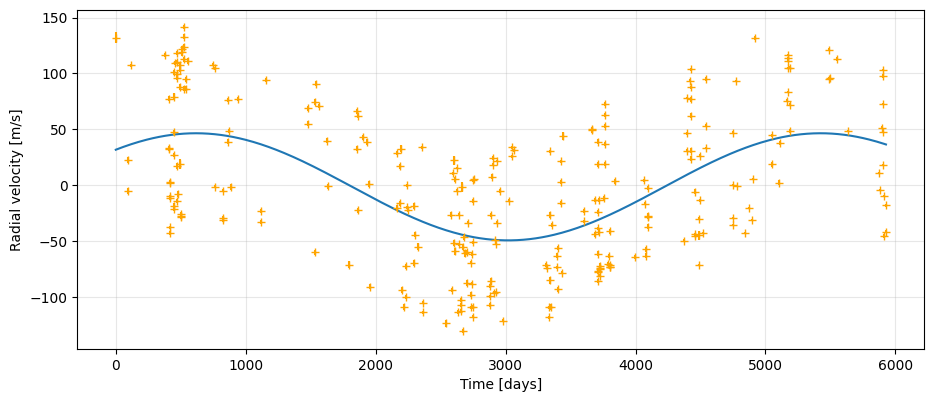

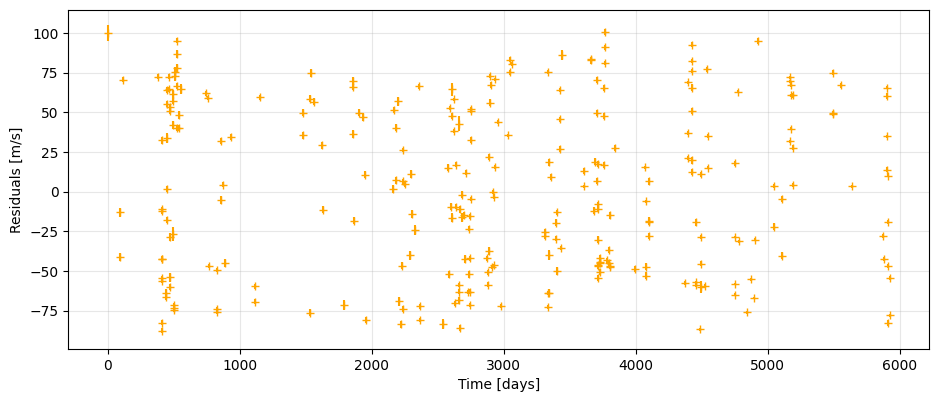

In [5]:
zoom_in = False

# ---- RV ----
x_model = np.linspace(x.min(),x.max(),500)
y_model = rv_model1(x_model,*param_opt1)

plt.plot(x_model,y_model)
plt.errorbar(x,y,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(250,500)
plt.show()

# ---- Residuals ----
# Compute residuals
residuals1 = y - rv_model1(x,*param_opt1)
# Plot residuals
plt.errorbar(x,residuals1,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Residuals [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(250,500)
plt.show()

The fit worked, and we can clearly tell visually that our model follows the trend of the data. Let us investigate the residuals.

In [6]:
print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}")

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840


The RMS of residuals is significantly smaller than the RMS of data. This is good, because it means our model extracted information from the data. However, the RMS is still pretty big, meaning there are other planets hiding in the data.

## Finding the second planet

All of you were lazy and used a Lomb-Scargle to get the period of the 2nd planet. I am even lazier than you: I can calculate the period and conjunction time of the 2nd planet by eye.

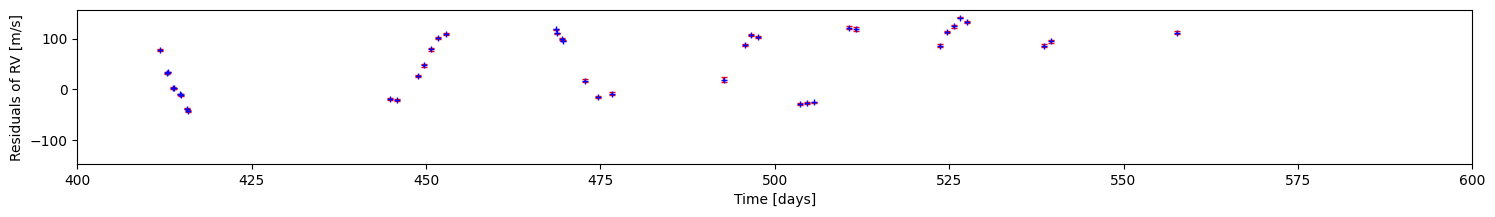

In [7]:
# plot the residuals, but zoom in from 400 to 600 days
fig,ax = plt.subplots(figsize=(18,2))

plt.errorbar(x,y,yerr,
             ls='',marker='+',markersize=5,capsize=2,color='blue',ecolor='red')

plt.xlabel("Time [days]")
plt.ylabel("Residuals of RV [m/s]")
plt.xlim(400,600)

plt.show()

It's a fun exercise to do by hand, but for the sake of time and clarity let's directly use the period given by the Lomb-Scargle and do a 1-planet fit on the residuals 1.

In [8]:
frequency, power = LombScargle(rv_data["HJD"]-rv_data["HJD"][0] , rv_data["RV"], rv_data["RV_err"]).autopower() 
best_frequency = frequency[np.argmax(power)]
P2_LS = 1.0 / best_frequency

print("P2 from LS:",P2_LS)

P2 from LS: 14.654489097650517


In [9]:
# initial guesses
K2 = 100.0
P2 = P2_LS
T2 = 450.0 
Vz = 0

# array containing initial guesses
p_init = np.asarray([Vz,K2,P2,T2])

x = rv_data["HJD"]-rv_data["HJD"][0]
y = residuals1
yerr = rv_data["RV_err"]

param_opt11, pcov11 = curve_fit(
    rv_model1,
    x,
    y,
    p0=p_init,
    sigma=yerr,
    absolute_sigma=True
)

param_err11 = np.sqrt(np.diag(pcov11))

# -------------------------------------------------------
# 5) Print comparison table
# -------------------------------------------------------
param_names = ["Vz", "K2", "P2", "T2"]

df = pd.DataFrame({
    "Parameter": param_names,
    "Initial guess": p_init,
    "Best fit": param_opt11,
    "1σ uncertainty": param_err11
})

display(df)

,Parameter,Initial guess,Best fit,1σ uncertainty
0,Vz,0.000000,2.654927,0.092973
1,K2,100.000000,71.301247,0.128562
2,P2,14.654489,14.652447,0.000040
3,T2,450.000000,449.545329,0.009769


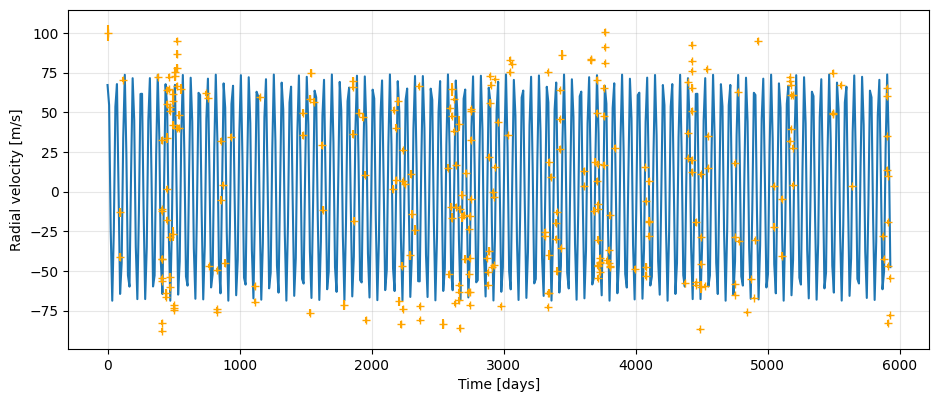

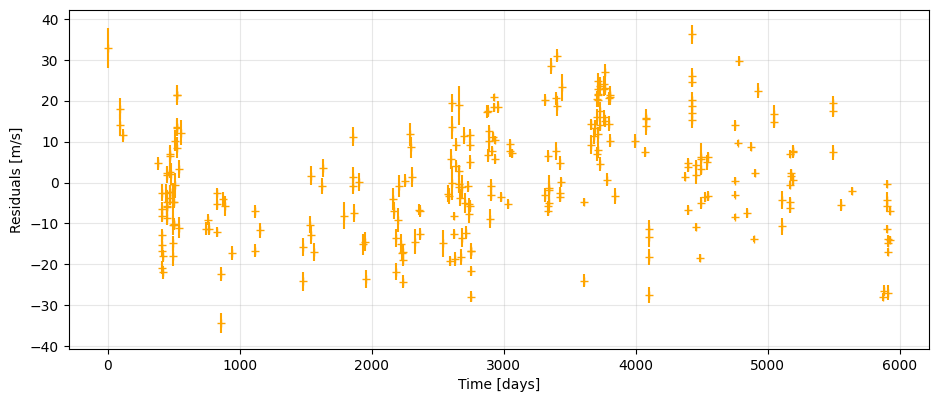

In [10]:
zoom_in = False

# ---- RV ----
x_model = np.linspace(x.min(),x.max(),500)
y_model = rv_model1(x_model,*param_opt11)

plt.plot(x_model,y_model)
plt.errorbar(x,y,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(250,500)
plt.show()

# ---- Residuals ----
# Compute residuals
residuals11 = residuals1 - rv_model1(x,*param_opt11)
# Plot residuals
plt.errorbar(x,residuals11,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Residuals [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(250,500)
plt.show()

In [11]:
print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}")
print(f"Residuals 1+1 RMS: {rms(residuals11):.6f}")

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840
Residuals 1+1 RMS: 13.701403


Both fit worked great, it's excellent.<br>

However, at this point I remind myself: the fit of the first planet was very rough, so I expect the offset 1 to be bad. This means it is safest to do a 2-planet fit before moving further.

## 2 planets analysis

Both planets are well-fitted with sine waves, so let's keep it like this, and use previous information as initial guesses.

In [12]:
def rv_model2(time, Vz, K1, P1, T1, K2, P2, T2):

    rv = K1*np.sin(2.0*np.pi*(time-T1)/P1) +\
         K2*np.sin(2.0*np.pi*(time-T2)/P2) + Vz
    
    return rv 

In [13]:
# make some initial guesses
# first planet
Vz = param_opt1[0]
K1 = param_opt1[1]
P1 = param_opt1[2]
T1 = param_opt1[3]

# second planet
K2 = param_opt11[1]
P2 = param_opt11[2]
T2 = param_opt11[3]

# array containing initial guesses
p_init = np.asarray([Vz,K1,P1,T1,K2,P2,T2])

x = rv_data["HJD"]-rv_data["HJD"][0]
y = rv_data["RV"]
yerr = rv_data["RV_err"]

param_opt2, pcov2 = curve_fit(
    rv_model2,
    x,
    y,
    p0=p_init,
    sigma=yerr,
    absolute_sigma=True
)

param_err2 = np.sqrt(np.diag(pcov2))

# -------------------------------------------------------
# 5) Print comparison table
# -------------------------------------------------------
param_names = ["Vz", "K1", "P1", "T1", "K2", "P2", "T2"]

df = pd.DataFrame({
    "Parameter": param_names,
    "Initial guess": p_init,
    "Best fit": param_opt2,
    "1σ uncertainty": param_err2
})

display(df)

,Parameter,Initial guess,Best fit,1σ uncertainty
0,Vz,-1.418196,0.030702,0.099086
1,K1,47.917696,44.255429,0.116881
2,P1,4807.046793,4847.583445,10.425367
3,T1,4221.912786,4043.534119,2.862279
4,K2,71.301247,72.497508,0.129568
5,P2,14.652447,14.652276,0.000040
6,T2,449.545329,449.558039,0.009691


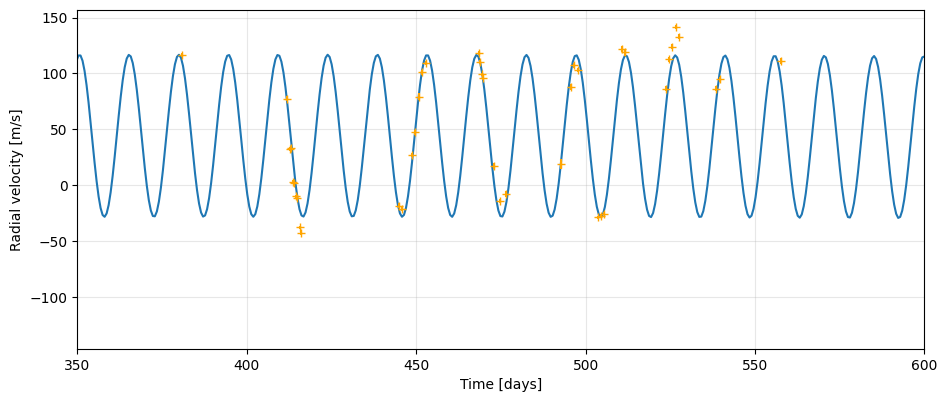

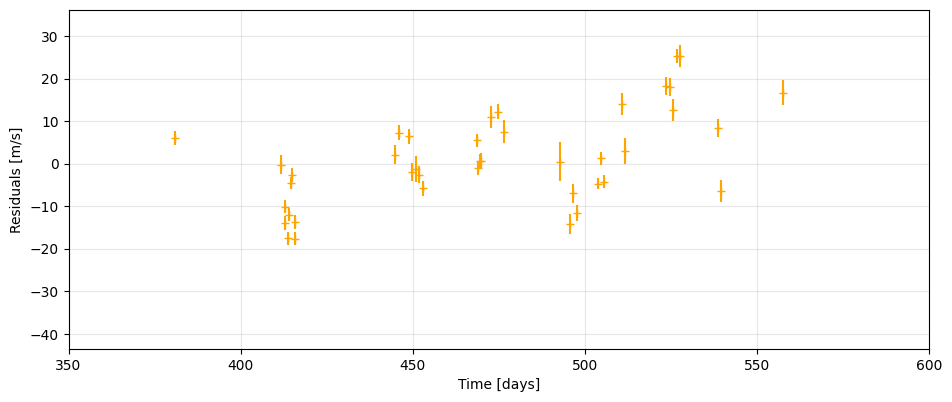

In [14]:
zoom_in = True

# ---- RV ----
x_model = np.linspace(x.min(),x.max(),10000)
y_model = rv_model2(x_model,*param_opt2)

plt.plot(x_model,y_model)
plt.errorbar(x,y,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

# ---- Residuals ----
# Compute residuals
residuals2 = y - rv_model2(x,*param_opt2)
# Plot residuals
plt.errorbar(x,residuals2,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Residuals [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

In [15]:
print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}")
print(f"Residuals 1+1 RMS: {rms(residuals11):.6f}")
print(f"Residuals 2 RMS: {rms(residuals2):.6f}")

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840
Residuals 1+1 RMS: 13.701403
Residuals 2 RMS: 11.706875


Notice how the simple fact that we are now fitting 2 planets at the same time (with an excellent initial guess from our previous analysis) we can refine the RMS of residuals so much.<br>

We do not need to the work in 2 steps each time. We can directly build a 3-planet model and fit it.

## Finding the 3rd planet

The Lomb-Scargle will tell us the period, and we'll move on from that.

In [16]:
frequency, power = LombScargle(rv_data["HJD"]-rv_data["HJD"][0] , residuals2, rv_data["RV_err"]).autopower() 
best_frequency = frequency[np.argmax(power)]
P3_LS = 1.0 / best_frequency

print("P3 from LS:",P3_LS)

P3 from LS: 44.4025531086115


In [17]:
def rv_model3(time, Vz, K1, P1, T1, K2, P2, T2, K3, P3, T3):
    rv = K1*np.sin(2.0*np.pi*(time-T1)/P1) +\
         K2*np.sin(2.0*np.pi*(time-T2)/P2) +\
         K3*np.sin(2.0*np.pi*(time-T3)/P3) + Vz
    return rv 

In [18]:
# make some initial guesses
# first planet
Vz = param_opt2[0]
K1 = param_opt2[1]
P1 = param_opt2[2]
T1 = param_opt2[3]

# second planet
K2 = param_opt2[4]
P2 = param_opt2[5]
T2 = param_opt2[6]

# third planet
K3 = 20 #from the RMS of residuals 2
P3 = P3_LS #from LS
T3 = 0 #no clue

# array containing initial guesses
p_init = np.asarray([Vz,K1,P1,T1,K2,P2,T2,K3,P3,T3])

x = rv_data["HJD"]-rv_data["HJD"][0]
y = rv_data["RV"]
yerr = rv_data["RV_err"]

param_opt3, pcov3 = curve_fit(
    rv_model3,
    x,
    y,
    p0=p_init,
    sigma=yerr,
    absolute_sigma=True
)

param_err3 = np.sqrt(np.diag(pcov3))

# -------------------------------------------------------
# 5) Print comparison table
# -------------------------------------------------------
param_names3 = ["Vz", "K1", "P1", "T1", "K2", "P2", "T2", "K3", "P3", "T3"]

df = pd.DataFrame({
    "Parameter": param_names3,
    "Initial guess": p_init,
    "Best fit": param_opt3,
    "1σ uncertainty": param_err3
})

display(df)

,Parameter,Initial guess,Best fit,1σ uncertainty
0,Vz,0.030702,0.342836,0.100023
1,K1,44.255429,45.183779,0.119080
2,P1,4847.583445,4847.551492,10.453016
3,T1,4043.534119,4063.814697,2.858856
4,K2,72.497508,72.508195,0.129847
5,P2,14.652276,14.652070,0.000040
6,T2,449.558039,449.648869,0.009738
7,K3,20.000000,-11.823142,0.140266
8,P3,44.402553,44.366005,0.002085
9,T3,0.000000,2.314213,0.188265


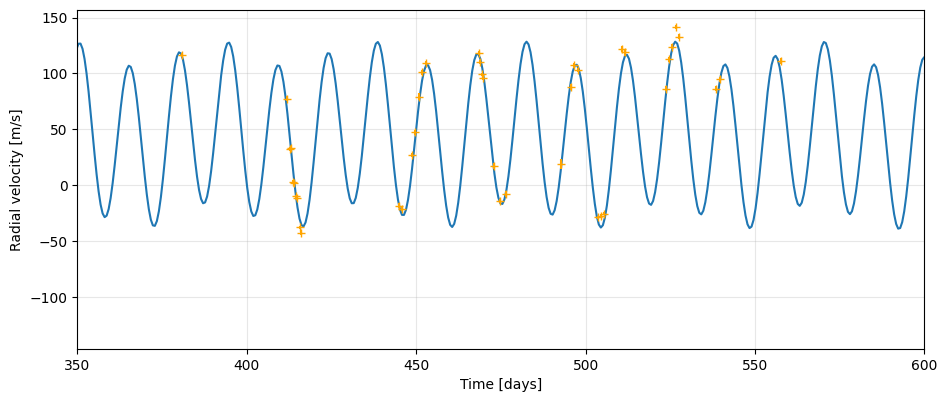

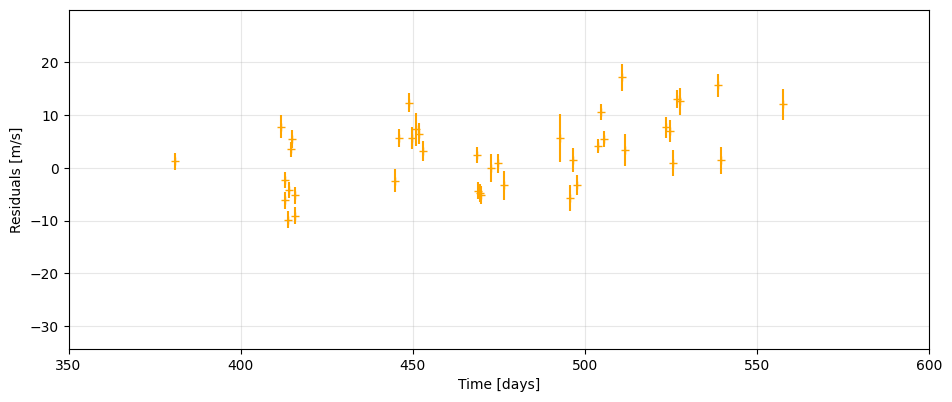

In [19]:
zoom_in = True

# ---- RV ----
x_model = np.linspace(x.min(),x.max(),10000)
y_model = rv_model3(x_model,*param_opt3)

plt.plot(x_model,y_model)
plt.errorbar(x,y,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

# ---- Residuals ----
# Compute residuals
residuals3 = y - rv_model3(x,*param_opt3)
# Plot residuals
plt.errorbar(x,residuals3,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Residuals [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

In [20]:
print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}")
print(f"Residuals 1+1 RMS: {rms(residuals11):.6f}")
print(f"Residuals 2 RMS: {rms(residuals2):.6f}")
print(f"Residuals 3 RMS: {rms(residuals3):.6f}")

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840
Residuals 1+1 RMS: 13.701403
Residuals 2 RMS: 11.706875
Residuals 3 RMS: 8.269160


The 3rd planet worked because we reduced the RMS by more than the data uncertainty.<br>
Notice how the addition of the 3rd planet refined the properties of planet 1.<br>
How far can we go?

### 4-planet fit

You know the drill...

At this point, I'll do everything in 1 cell so I can copy-paste everything.

P4 from LS: 261.133957709235


,Parameter,Initial guess,Best fit,1σ uncertainty
0,Vz,0.342836,0.670821,0.103535
1,K1,45.183779,45.887365,0.124364
2,P1,4847.551492,4960.888149,11.636463
3,T1,4063.814697,4087.333527,3.033664
4,K2,72.508195,72.462627,0.132792
5,P2,14.652070,14.651953,0.000041
6,T2,449.648869,449.662955,0.009751
7,K3,-11.823142,-11.755940,0.142309
8,P3,44.366005,44.364840,0.002143
9,T3,2.314213,2.306733,0.190301


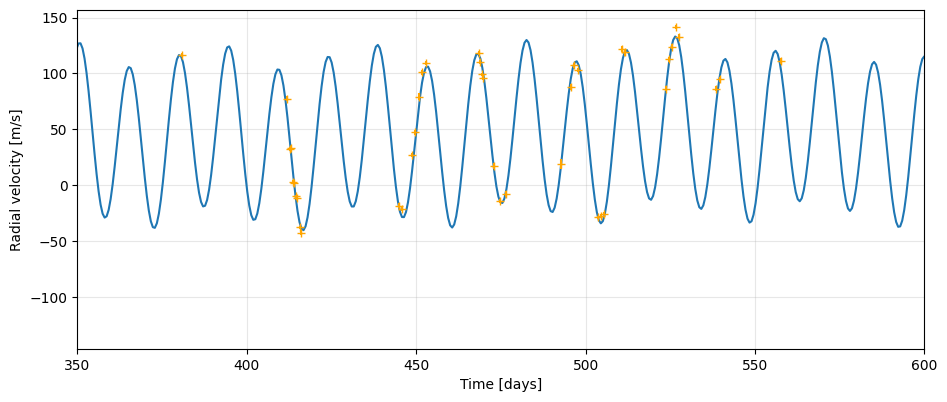

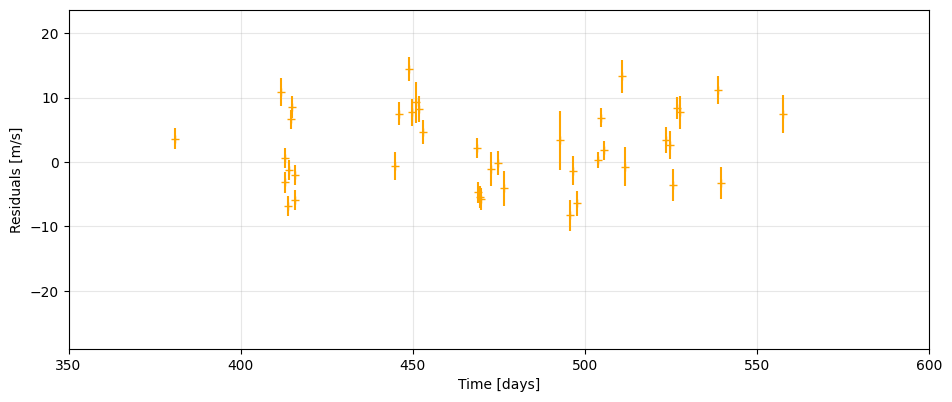

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840
Residuals 1+1 RMS: 13.701403
Residuals 2 RMS: 11.706875
Residuals 3 RMS: 8.269160
Residuals 4 RMS: 7.458880


In [21]:
frequency, power = LombScargle(rv_data["HJD"]-rv_data["HJD"][0] , residuals3, rv_data["RV_err"]).autopower() 
best_frequency = frequency[np.argmax(power)]
P4_LS = 1.0 / best_frequency

print("P4 from LS:",P4_LS)

def rv_model4(time, Vz, K1, P1, T1, K2, P2, T2, K3, P3, T3, K4, P4, T4):
    rv = K1*np.sin(2.0*np.pi*(time-T1)/P1) +\
         K2*np.sin(2.0*np.pi*(time-T2)/P2) +\
         K3*np.sin(2.0*np.pi*(time-T3)/P3) +\
         K4*np.sin(2.0*np.pi*(time-T4)/P4) + Vz
    return rv 

# make some initial guesses
# switching to a more compact approach to construct my arrays

# 4th planet
K4 = rms(residuals3)
P4 = P4_LS
T4 = 0

# array containing initial guesses
p_init = np.append(param_opt3,np.array([K4,P4,T4]))

x = rv_data["HJD"]-rv_data["HJD"][0]
y = rv_data["RV"]
yerr = rv_data["RV_err"]

param_opt4, pcov4 = curve_fit(
    rv_model4,
    x,
    y,
    p0=p_init,
    sigma=yerr,
    absolute_sigma=True
)

param_err4 = np.sqrt(np.diag(pcov4))

# -------------------------------------------------------
# 5) Print comparison table
# -------------------------------------------------------
param_names4 = param_names3+["K4", "P4", "T4"]

df = pd.DataFrame({
    "Parameter": param_names4,
    "Initial guess": p_init,
    "Best fit": param_opt4,
    "1σ uncertainty": param_err4
})

display(df)

zoom_in = True

# ---- RV ----
x_model = np.linspace(x.min(),x.max(),10000)
y_model = rv_model4(x_model,*param_opt4)

plt.plot(x_model,y_model)
plt.errorbar(x,y,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

# ---- Residuals ----
# Compute residuals
residuals4 = y - rv_model4(x,*param_opt4)
# Plot residuals
plt.errorbar(x,residuals4,yerr=yerr,marker="+",c="orange",ls="")
plt.xlabel("Time [days]")
plt.ylabel("Residuals [m/s]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10,4)
if zoom_in: plt.xlim(350,600)
plt.show()

print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}")
print(f"Residuals 1+1 RMS: {rms(residuals11):.6f}")
print(f"Residuals 2 RMS: {rms(residuals2):.6f}")
print(f"Residuals 3 RMS: {rms(residuals3):.6f}")
print(f"Residuals 4 RMS: {rms(residuals4):.6f}")

And this is where we stop (for me at least). It's not that the fit failed, but we're not sure if we're fitting signal or noise. I haven't tried fitting a full keplerian model, but it is possible that you could get a 4th planet (or even 5th) out of it. All I know is this is how far I can get with circular orbits, and that's already good.<br>

Another argument: notice what happens when you compare the RMS with the semi-amplitude:

In [22]:
print(f"Data RMS: {rms(rv_data["RV"]):.6f}")
print(f"Data uncertainty: {np.median(rv_data["RV_err"]):.6f}")
print(f"Residuals 1 RMS: {rms(residuals1):.6f}", f"K1 = {param_opt1[1]:.6f}",)
print(f"Residuals 1+1 RMS: {rms(residuals11):.6f}", f"K11 = {param_opt11[1]:.6f}",)
print(f"Residuals 2 RMS: {rms(residuals2):.6f}", f"K2 = {param_opt2[4]:.6f}",)
print(f"Residuals 3 RMS: {rms(residuals3):.6f}", f"K3 = {-param_opt3[7]:.6f}",)
print(f"Residuals 4 RMS: {rms(residuals4):.6f}", f"K4 = {param_opt4[10]:.6f}",)

Data RMS: 67.068499
Data uncertainty: 1.695000
Residuals 1 RMS: 52.244840 K1 = 47.917696
Residuals 1+1 RMS: 13.701403 K11 = 71.301247
Residuals 2 RMS: 11.706875 K2 = 72.497508
Residuals 3 RMS: 8.269160 K3 = 11.823142
Residuals 4 RMS: 7.458880 K4 = 4.521159


For all instances of fits that we claim have worked, the semi-amplitude is greater than the residual RMS (the signal is stronger than the leftover noise).

For the 4th "planet", the signal given by the fit is smaller than the noise. I wasn't expecting anyone to be this precise, the justification provided in the previous cell is sufficient.

## Calculating the mass of exoplanets


In [23]:
mass_star = 0.905
Vz,K1,P1,T1,K2,P2,T2,K3,P3,T3 = np.abs(param_opt3)

mass1 = (K1/28.4) * (P1/365)**(1/3) * mass_star**(2/3)
mass2 = (K2/28.4) * (P2/365)**(1/3) * mass_star**(2/3)
mass3 = (K3/28.4) * (P3/365)**(1/3) * mass_star**(2/3)

print(f"Planet 1 has a mass m2 sin(i) of {mass1:.4f} Mjup."+
      f"\nAccording to the exoplanet archive, Planet 1 is 55 Cnc d.")
print()
print(f"Planet 2 has a mass m2 sin(i) of {mass2:.4f} Mjup."+
      f"\nAccording to the exoplanet archive, Planet 2 is 55 Cnc b.")
print()
print(f"Planet 3 has a mass m2 sin(i) of {mass3:.4f} Mjup."+
      f"\nAccording to the exoplanet archive, Planet 3 is 55 Cnc c.")
print()
      

Planet 1 has a mass m2 sin(i) of 3.5251 Mjup.
According to the exoplanet archive, Planet 1 is 55 Cnc d.

Planet 2 has a mass m2 sin(i) of 0.8179 Mjup.
According to the exoplanet archive, Planet 2 is 55 Cnc b.

Planet 3 has a mass m2 sin(i) of 0.1929 Mjup.
According to the exoplanet archive, Planet 3 is 55 Cnc c.



## Conclusion and final remarks

The first objective of this homework was for your to practice your **coding skills**. You all did it, so it is a huge success.<br>

The second objective was to develop your **analysis and research skills** (how to approach a problem, and when to stop), which I found elements of in most of your work. There is room for improvement, but you are on the right track.<br>

The third objective was to develop your **analytical skills** (deriving analytical equations). This is where most of the points are missing from your grades, and where most work is needed.<br>

Lastly, the final objective was to develop your **ressourcefulness**: scale your efforts proportionally to the task. This is a very difficult skill to develop, but essential to become a professionnal (not just astronomer, but a professionnal at any job).<br>

